## 1. Prepare Data

In [1]:
from pathlib import Path
from mhdr.dataloader.process_multilabel_human_data import load_multilabel_human_data
from mhdr.dataloader.io import read_csv
import pandas as pd
from itertools import product
import os
INPUT_DIR = Path.cwd() / "input"
OUTPUT_DIR = Path.cwd() / "output"
TEMP_DIR = Path.cwd() / "temp"
DATA = read_csv(INPUT_DIR / "questions_master.csv")
DIMENSIONS = [
    "Emotional",
    "Environmental",
    "Financial",
    "Intellectual",
    "Occupational",
    "Physical",
    "Social",
    "Spiritual",
]

In [2]:
HUMAN_DATA = load_multilabel_human_data(INPUT_DIR, [DATA])
print(len(HUMAN_DATA))
HUMAN_DATA.head()

3480


,qid,text,Emotional,Environmental,Financial,Intellectual,Occupational,Physical,Social,Spiritual
0,CD_RISC_1,I am able to adapt when changes occur.,2,0,0,1,0,0,0,0
1,CD_RISC_1,I am able to adapt when changes occur.,3,0,0,1,0,0,0,2
2,CD_RISC_1,I am able to adapt when changes occur.,1,0,0,0,0,0,3,2
3,CD_RISC_1,I am able to adapt when changes occur.,3,1,0,0,0,0,0,2
4,CD_RISC_1,I am able to adapt when changes occur.,0,3,0,1,0,0,2,0


In [3]:
from sklearn.model_selection import train_test_split
import tempfile
from pathlib import Path


def split_by_qid(df):

    qids = df["qid"].unique()

    train_qid, temp_qid = train_test_split(
        qids,
        test_size=0.3,
        random_state=42
    )

    val_qid, test_qid = train_test_split(
        temp_qid,
        test_size=0.5,
        random_state=42
    )

    train_df = df[df["qid"].isin(train_qid)]
    val_df   = df[df["qid"].isin(val_qid)]
    test_df  = df[df["qid"].isin(test_qid)]

    return train_df, val_df, test_df


train_df, val_df, test_df = split_by_qid(HUMAN_DATA)

train_df.to_csv(TEMP_DIR / "train.csv", index=False)
val_df.to_csv(TEMP_DIR / "val.csv", index=False)
test_df.to_csv(TEMP_DIR / "test.csv", index=False)

In [4]:
def aggregate_soft_labels(df, dimensions, qid_col="qid", text_col="text"):
    rows = []

    grouped = df.groupby(qid_col, sort=False)

    for qid, g in grouped:
        row = {
            qid_col: qid,
            text_col: g[text_col].iloc[0],
            "n_annotators": len(g),
        }

        # soft selection target: proportion of annotators who selected this dimension
        sel = (g[dimensions] > 0).astype(float)
        mean_sel = sel.mean(axis=0)

        for d in dimensions:
            row[d] = float(mean_sel[d])

        rows.append(row)

    out = pd.DataFrame(rows)
    return out[[qid_col, text_col, "n_annotators"] + dimensions]

In [5]:
train_soft = aggregate_soft_labels(train_df, DIMENSIONS)
val_soft = aggregate_soft_labels(val_df, DIMENSIONS)
test_soft = aggregate_soft_labels(test_df, DIMENSIONS)

print(train_soft.head())
print(len(train_soft), len(val_soft), len(test_soft))

          qid                                               text  \
0  CD_RISC_10             I make my best effort, no matter what.   
1  CD_RISC_11  I believe I can achieve my goals, even if ther...   
2  CD_RISC_12              Even when hopeless, I do not give up.   
3  CD_RISC_14  Under pressure, I stay focused and think clearly.   
4  CD_RISC_15      I prefer to take the lead in problem-solving.   

   n_annotators  Emotional  Environmental  Financial  Intellectual  \
0            27   0.851852       0.259259   0.222222      0.666667   
1            27   0.925926       0.259259   0.148148      0.703704   
2            27   0.851852       0.148148   0.111111      0.296296   
3            27   0.851852       0.296296   0.148148      0.851852   
4            27   0.518519       0.259259   0.185185      0.962963   

   Occupational  Physical    Social  Spiritual  
0      0.666667  0.296296  0.370370   0.518519  
1      0.592593  0.333333  0.185185   0.555556  
2      0.185185  0.1851

## 2. Find the Best Parameter

In [6]:
from mhdr.single_classifier.selection_classifier import SelectionClassifier
import pandas as pd
import torch
import numpy as np

/Users/haikeyu/Desktop/mentalhealth-dimension-reduction/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import os
import pandas as pd

csv_path = "selection_hyperparam_search.csv"

clf = SelectionClassifier(
    dimensions=DIMENSIONS,
    embedding_model="all-MiniLM-L6-v2",
)

if os.path.exists(csv_path):
    existing_df = pd.read_csv(csv_path)
    print("Existing search results:")
    print(existing_df.head())

else:
    existing_df = pd.DataFrame()

search_df = clf.search_train_hyperparams(
    train_df=train_soft,
    val_df=val_soft,
    lr_list=[1e-3, 7e-4, 5e-4, 3e-4, 2e-4],
    hidden_dim_list=[128, 256, 512],
    dropout_list=[0.0, 0.1, 0.2],
    epochs=40,
    batch_size=16,
    text_col="text",
    patience=5,
    save_csv=csv_path,
)

print("\nFull search results:")
print(search_df)

best_row = search_df.iloc[0]

print("\nBest hyperparams:")
print(best_row)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1830.08it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Existing search results:
       lr  hidden_dim  dropout  val_loss   val_bce
0  0.0010         512      0.0  0.497668  0.497668
1  0.0010         512      0.2  0.499118  0.499118
2  0.0010         512      0.1  0.499566  0.499566
3  0.0007         512      0.0  0.499773  0.499773
4  0.0007         512      0.2  0.499805  0.499805
Loaded existing search results: 45 rows
Skipping existing config: lr=0.001, hidden_dim=128, dropout=0.0
Skipping existing config: lr=0.001, hidden_dim=128, dropout=0.1
Skipping existing config: lr=0.001, hidden_dim=128, dropout=0.2
Skipping existing config: lr=0.001, hidden_dim=256, dropout=0.0
Skipping existing config: lr=0.001, hidden_dim=256, dropout=0.1
Skipping existing config: lr=0.001, hidden_dim=256, dropout=0.2
Skipping existing config: lr=0.001, hidden_dim=512, dropout=0.0
Skipping existing config: lr=0.001, hidden_dim=512, dropout=0.1
Skipping existing config: lr=0.001, hidden_dim=512, dropout=0.2
Skipping existing config: lr=0.0007, hidden_dim=128, 

## 3. Train the Model with the Bset Parameter

In [8]:
best_clf = SelectionClassifier(
    dimensions=DIMENSIONS,
    embedding_model="all-MiniLM-L6-v2",
    hidden_dim=int(best_row["hidden_dim"]),
    dropout=float(best_row["dropout"]),
)

best_clf.fit(
    train_df=train_soft,
    val_df=val_soft,
    epochs=40,
    batch_size=16,
    lr=float(best_row["lr"]),
    text_col="text",
    patience=5,
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 429.92it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 3/3 [00:00<00:00,  7.87it/s]


Epoch 1/40 | train_loss=0.6814 (bce=0.6814) | val_loss=0.6647 (bce=0.6647)
Epoch 2/40 | train_loss=0.6515 (bce=0.6515) | val_loss=0.6341 (bce=0.6341)
Epoch 3/40 | train_loss=0.6168 (bce=0.6168) | val_loss=0.6004 (bce=0.6004)
Epoch 4/40 | train_loss=0.5816 (bce=0.5816) | val_loss=0.5764 (bce=0.5764)
Epoch 5/40 | train_loss=0.5570 (bce=0.5570) | val_loss=0.5654 (bce=0.5654)
Epoch 6/40 | train_loss=0.5453 (bce=0.5453) | val_loss=0.5571 (bce=0.5571)
Epoch 7/40 | train_loss=0.5352 (bce=0.5352) | val_loss=0.5469 (bce=0.5469)
Epoch 8/40 | train_loss=0.5231 (bce=0.5231) | val_loss=0.5364 (bce=0.5364)
Epoch 9/40 | train_loss=0.5118 (bce=0.5118) | val_loss=0.5283 (bce=0.5283)
Epoch 10/40 | train_loss=0.5030 (bce=0.5030) | val_loss=0.5224 (bce=0.5224)
Epoch 11/40 | train_loss=0.4954 (bce=0.4954) | val_loss=0.5183 (bce=0.5183)
Epoch 12/40 | train_loss=0.4897 (bce=0.4897) | val_loss=0.5156 (bce=0.5156)
Epoch 13/40 | train_loss=0.4848 (bce=0.4848) | val_loss=0.5138 (bce=0.5138)
Epoch 14/40 | train_l

In [9]:
val_metrics = best_clf.evaluate_loss(val_soft, text_col="text")
test_metrics = best_clf.evaluate_loss(test_soft, text_col="text")

print("val:", val_metrics)
print("test:", test_metrics)

val: {'loss': 0.49911385774612427, 'bce': 0.49911385774612427}
test: {'loss': 0.5242156386375427, 'bce': 0.5242156386375427}


## 4. Human Baseline

In [10]:
from mhdr.single_classifier.human_baseline import compute_bce_lower_bound

In [11]:
lower_val = compute_bce_lower_bound(
    df=val_soft,
    dimensions=DIMENSIONS,
)
lower_test = compute_bce_lower_bound(
    df=test_soft,
    dimensions=DIMENSIONS,
)
print("Val BCE lower bound:", lower_val["bce_lower_bound"])
print("Test BCE lower bound:", lower_test["bce_lower_bound"])

Val BCE lower bound: 0.44887247681617737
Test BCE lower bound: 0.4728050172328949


## 5. Compare 

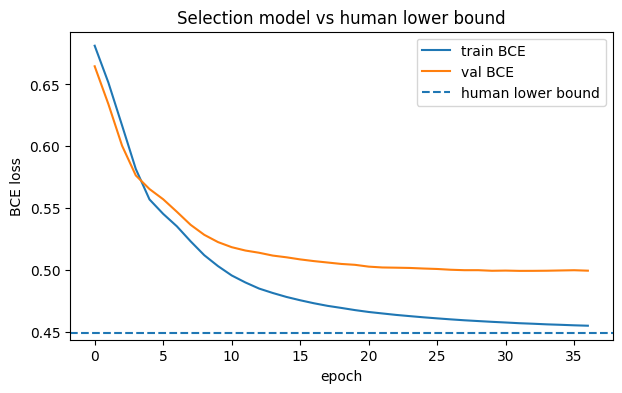

In [12]:
import matplotlib.pyplot as plt

train_bce = [m["bce"] for m in best_clf.train_losses]
val_bce = [m["bce"] for m in best_clf.val_losses]

lower_bound = lower_val["bce_lower_bound"]

plt.figure(figsize=(7,4))

plt.plot(train_bce, label="train BCE")
plt.plot(val_bce, label="val BCE")

plt.axhline(
    lower_bound,
    linestyle="--",
    label="human lower bound"
)

plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("Selection model vs human lower bound")

plt.legend()
plt.show()

## 6. Search Threshhold

In [13]:
from mhdr.single_classifier.postprocess import search_best_threshold, evaluate_selection_threshold

In [14]:
th_df = search_best_threshold(
    model=best_clf,
    val_df=val_df,  
    dimensions=DIMENSIONS,
    text_col="text",
    sort_by="f1",
    thresholds=np.arange(0.0, 1.01, 0.05),
)

print(th_df)
best_th_row = th_df.iloc[0]

print("\nBest threshold row:")
print(best_th_row)

    threshold  precision    recall        f1  exact_match
0        0.40   0.675737  0.625175  0.649473     0.185824
1        0.35   0.630156  0.651748  0.640770     0.162835
2        0.45   0.710145  0.582517  0.640031     0.249042
3        0.30   0.583777  0.689510  0.632254     0.130268
4        0.50   0.748778  0.535664  0.624541     0.247126
5        0.25   0.524719  0.749650  0.617334     0.132184
6        0.20   0.471360  0.828671  0.600913     0.053640
7        0.55   0.762215  0.490909  0.597193     0.252874
8        0.60   0.797980  0.441958  0.568857     0.262452
9        0.15   0.414318  0.894406  0.566305     0.017241
10       0.65   0.787634  0.409790  0.539098     0.254789
11       0.10   0.357978  0.985315  0.525158     0.074713
12       0.00   0.342433  1.000000  0.510168     0.086207
13       0.05   0.342433  1.000000  0.510168     0.086207
14       0.70   0.803922  0.372727  0.509317     0.258621
15       0.75   0.855750  0.306993  0.451879     0.245211
16       0.80 

## 7. Evaluate

In [15]:
test_metrics = evaluate_selection_threshold(
    model=best_clf,
    df=test_df,
    dimensions=DIMENSIONS,
    text_col="text",
    threshold=best_th_row["threshold"],
)

print("\nTest metrics:")
print(test_metrics)


Test metrics:
{'threshold': np.float64(0.4), 'precision': np.float64(0.6831372549019608), 'recall': np.float64(0.5768211920529801), 'f1': np.float64(0.6254937163375224), 'exact_match': np.float64(0.1980952380952381)}


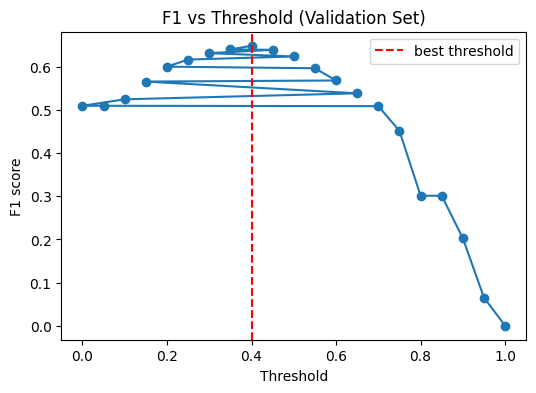

In [16]:
plt.figure(figsize=(6,4))

plt.plot(th_df["threshold"], th_df["f1"], marker="o")

plt.axvline(
    float(best_th_row["threshold"]),
    linestyle="--",
    color="red",
    label="best threshold"
)

plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("F1 vs Threshold (Validation Set)")

plt.legend()
plt.show()

In [17]:
test_items = [
    ("TEST_1", "I feel disconnected from my friends."),
    ("TEST_2", "I feel overwhelmed by my emotions."),
    ("TEST_3", "My body feels tired and drained."),
    ("TEST_4", "I worry about my financial future."),
    ("TEST_5", "I enjoy challenging my mind with new ideas."),
    ("TEST_6", "My life feels connected to a deeper purpose."),
    ("TEST_7", "My living environment makes me uncomfortable."),
    ("TEST_8", "I am able to adapt when changes occur"),
]

best_threshold = float(best_th_row["threshold"])

for qid, text in test_items:
    scores = best_clf.predict_scores([text])[0]
    probs = best_clf.predict_probs([text])[0]

    selected_idx = np.where(probs >= best_threshold)[0]
    selected_sorted = selected_idx[np.argsort(scores[selected_idx])[::-1]]

    rank_dict = {d: 0 for d in DIMENSIONS}
    for rank, idx in enumerate(selected_sorted, start=1):
        rank_dict[DIMENSIONS[idx]] = rank

    print("=" * 60)
    print(qid, text)
    print(f"threshold = {best_threshold:.2f}")

    print("\nProbabilities:")
    print(pd.Series(probs, index=DIMENSIONS).sort_values(ascending=False))

    print("\nSelected dimensions:")
    print([DIMENSIONS[i] for i in selected_sorted])

    print("\nRank vector:")
    print(rank_dict)

TEST_1 I feel disconnected from my friends.
threshold = 0.40

Probabilities:
Social           0.950055
Emotional        0.757068
Environmental    0.191781
Spiritual        0.121653
Intellectual     0.083018
Physical         0.052343
Occupational     0.045458
Financial        0.041437
dtype: float32

Selected dimensions:
['Social', 'Emotional']

Rank vector:
{'Emotional': 2, 'Environmental': 0, 'Financial': 0, 'Intellectual': 0, 'Occupational': 0, 'Physical': 0, 'Social': 1, 'Spiritual': 0}
TEST_2 I feel overwhelmed by my emotions.
threshold = 0.40

Probabilities:
Emotional        0.895458
Social           0.336431
Intellectual     0.311316
Spiritual        0.274576
Environmental    0.193618
Physical         0.103839
Occupational     0.102421
Financial        0.065166
dtype: float32

Selected dimensions:
['Emotional']

Rank vector:
{'Emotional': 1, 'Environmental': 0, 'Financial': 0, 'Intellectual': 0, 'Occupational': 0, 'Physical': 0, 'Social': 0, 'Spiritual': 0}
TEST_3 My body feels t

In [18]:
import numpy as np
import pandas as pd
from itertools import combinations


def compute_human_pairwise_f1(
    df: pd.DataFrame,
    dimensions: list[str],
    qid_col: str = "qid",
) -> dict:
    """
    Compute human-human pairwise micro-F1 within each qid.

    Assumes:
    - each row = one annotator response
    - multiple rows may share the same qid
    - no annotator_id is required

    For each qid:
    - convert rank labels to binary selection (y > 0)
    - compare all row pairs within that qid
    - average F1 across all valid pairs
    """

    pair_f1s = []
    n_qids_used = 0
    n_pairs = 0

    grouped = df.groupby(qid_col, sort=False)

    for _, g in grouped:
        y = (g[dimensions].to_numpy(dtype=np.float32) > 0).astype(np.int32)

        if len(y) < 2:
            continue

        n_qids_used += 1

        for i, j in combinations(range(len(y)), 2):
            y_i = y[i]
            y_j = y[j]

            tp = ((y_i == 1) & (y_j == 1)).sum()
            fp = ((y_i == 1) & (y_j == 0)).sum()
            fn = ((y_i == 0) & (y_j == 1)).sum()

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = (
                2 * precision * recall / (precision + recall)
                if (precision + recall) > 0 else 0.0
            )

            pair_f1s.append(f1)
            n_pairs += 1

    mean_f1 = float(np.mean(pair_f1s)) if pair_f1s else 0.0
    std_f1 = float(np.std(pair_f1s)) if pair_f1s else 0.0

    return {
        "human_pairwise_f1_mean": mean_f1,
        "human_pairwise_f1_std": std_f1,
        "n_qids_used": n_qids_used,
        "n_pairs": n_pairs,
    }

In [19]:
human_f1_stats = compute_human_pairwise_f1(
    test_df,
    DIMENSIONS,
    qid_col="qid",
)

human_f1 = human_f1_stats["human_pairwise_f1_mean"]
model_f1 = test_metrics["f1"]

print("Human F1:", human_f1)
print("Model F1:", model_f1)

print("Difference (model - human):", model_f1 - human_f1)

Human F1: 0.5489385536332452
Model F1: 0.6254937163375224
Difference (model - human): 0.0765551627042772


## 8. Find the Best Parameter

In [20]:
from mhdr.single_classifier.rank_classifier import RankingClassifier

In [21]:
import os
import pandas as pd

rank_clf = RankingClassifier(
    dimensions=DIMENSIONS,
    embedding_model="all-MiniLM-L6-v2",
)

search_file = "ranking_hyperparam_search_tiny2s.csv"

if os.path.exists(search_file):
    print("Loading existing ranking hyperparam search...")
    rank_search_df = pd.read_csv(search_file)
else:
    rank_search_df = rank_clf.search_train_hyperparams(
        train_df=train_df,
        val_df=val_df,
        lr_list=[1e-3, 7e-4, 5e-4, 3e-4],
        hidden_dim_list=[4, 8],
        dropout_list=[0.0],
        margin_list=[0.01, 0.02],
        epochs=15,
        batch_size=16,
        text_col="text",
        patience=2,
        save_csv=search_file,
    )

print(rank_search_df)

best_rank_row = rank_search_df.sort_values("val_loss").iloc[0]

print("\nBest ranking hyperparams:")
print(best_rank_row)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1783.79it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading existing ranking hyperparam search...
        lr  hidden_dim  dropout  margin  val_loss  val_rank  n_pairs  \
0   0.0005           4      0.0    0.01  0.009241  0.009241     2323   
1   0.0010           8      0.0    0.01  0.010753  0.010753     2323   
2   0.0007           8      0.0    0.01  0.010967  0.010967     2323   
3   0.0007           4      0.0    0.01  0.012070  0.012070     2323   
4   0.0005           8      0.0    0.01  0.013184  0.013184     2323   
5   0.0010           4      0.0    0.01  0.013442  0.013442     2323   
6   0.0003           8      0.0    0.01  0.015171  0.015171     2323   
7   0.0003           4      0.0    0.01  0.015942  0.015942     2323   
8   0.0003           8      0.0    0.02  0.017661  0.017661     2323   
9   0.0010           8      0.0    0.02  0.017684  0.017684     2323   
10  0.0010           4      0.0    0.02  0.017805  0.017805     2323   
11  0.0007           8      0.0    0.02  0.019301  0.019301     2323   
12  0.0005        

## 9. Train the Model with best Hyperparameter

In [22]:
best_rank_clf = RankingClassifier(
    dimensions=DIMENSIONS,
    embedding_model="all-MiniLM-L6-v2",
    hidden_dim=int(best_rank_row["hidden_dim"]),
    dropout=float(best_rank_row["dropout"]),
    margin=float(best_rank_row["margin"]),
)

best_rank_clf.fit(
    train_df=train_df,
    val_df=val_df,
    epochs=40,
    batch_size=16,
    lr=float(best_rank_row["lr"]),
    text_col="text",
    patience=5,
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1809.75it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 77/77 [00:01<00:00, 53.50it/s]


Epoch 1/40 | train_rank=0.0961 (pairs=11167, skipped=1) | val_rank=0.0736 (pairs=2323)
Epoch 2/40 | train_rank=0.0484 (pairs=11167, skipped=0) | val_rank=0.0265 (pairs=2323)
Epoch 3/40 | train_rank=0.0168 (pairs=11167, skipped=0) | val_rank=0.0130 (pairs=2323)
Epoch 4/40 | train_rank=0.0096 (pairs=11167, skipped=1) | val_rank=0.0116 (pairs=2323)
Epoch 5/40 | train_rank=0.0089 (pairs=11167, skipped=0) | val_rank=0.0118 (pairs=2323)
Epoch 6/40 | train_rank=0.0087 (pairs=11167, skipped=0) | val_rank=0.0115 (pairs=2323)
Epoch 7/40 | train_rank=0.0086 (pairs=11167, skipped=1) | val_rank=0.0110 (pairs=2323)
Epoch 8/40 | train_rank=0.0085 (pairs=11167, skipped=0) | val_rank=0.0117 (pairs=2323)
Epoch 9/40 | train_rank=0.0086 (pairs=11167, skipped=1) | val_rank=0.0114 (pairs=2323)
Epoch 10/40 | train_rank=0.0085 (pairs=11167, skipped=1) | val_rank=0.0114 (pairs=2323)
Epoch 11/40 | train_rank=0.0086 (pairs=11167, skipped=0) | val_rank=0.0116 (pairs=2323)
Epoch 12/40 | train_rank=0.0086 (pairs=11

In [23]:
rank_val_metrics = best_rank_clf.evaluate_loss(
    val_df,
    text_col="text",
)

rank_test_metrics = best_rank_clf.evaluate_loss(
    test_df,
    text_col="text",
)

print("Rank VAL:", rank_val_metrics)
print("Rank TEST:", rank_test_metrics)

Rank VAL: {'loss': 0.011000449028911709, 'rank': 0.011000449028911709, 'n_pairs': 2323, 'skipped_batches': 0}
Rank TEST: {'loss': 0.01234607082172905, 'rank': 0.01234607082172905, 'n_pairs': 2443, 'skipped_batches': 0}


## 10. Human

In [24]:
from mhdr.single_classifier.human_baseline import compute_rank_lower_bound

In [25]:
rank_lower = compute_rank_lower_bound(
    df=val_df,          
    dimensions=DIMENSIONS,
    qid_col="qid",
    margin=float(best_rank_row["margin"]),
    lr=0.1,
    steps=300,
)

print(rank_lower)

{'rank_lower_bound': 0.008036274407411758, 'n_pairs': 2323, 'n_qids': 15, 'margin': 0.01, 'lr': 0.1, 'steps': 300}


## 11. Compare

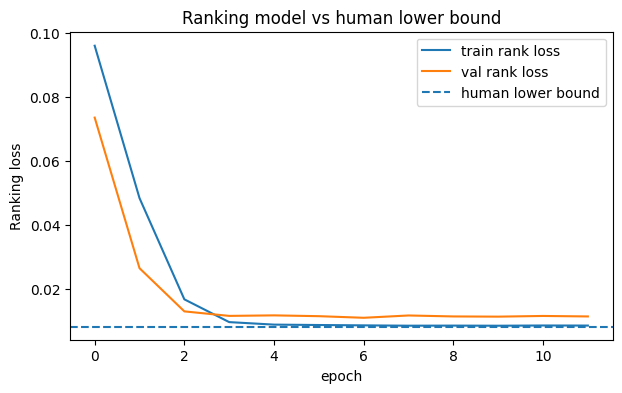

In [26]:
import matplotlib.pyplot as plt

train_rank = [m["rank"] for m in best_rank_clf.train_losses]
val_rank = [m["rank"] for m in best_rank_clf.val_losses]

lower_bound = rank_lower["rank_lower_bound"]

plt.figure(figsize=(7,4))

plt.plot(train_rank, label="train rank loss")
plt.plot(val_rank, label="val rank loss")

plt.axhline(
    lower_bound,
    linestyle="--",
    label="human lower bound"
)

plt.xlabel("epoch")
plt.ylabel("Ranking loss")
plt.title("Ranking model vs human lower bound")

plt.legend()
plt.show()

In [27]:
import numpy as np
from itertools import combinations

# =========================================================
# 1. selection + rank pipeline
# =========================================================
def selection_rank_pipeline(
    sel_probs,
    rank_scores,
    threshold,
    dimensions,
):
    results = []

    for p, r in zip(sel_probs, rank_scores):
        selected = np.where(p >= threshold)[0]

        out = np.zeros(len(dimensions), dtype=np.float32)

        if len(selected) > 0:
            order = selected[np.argsort(r[selected])[::-1]]

            for rank, idx in enumerate(order, start=1):
                out[idx] = rank

        results.append(out)

    return np.array(results, dtype=np.float32)


# =========================================================
# 2. selection-only ranking baseline
# =========================================================
def selection_only_rank_pipeline(
    sel_probs,
    sel_scores,
    threshold,
    dimensions,
):
    results = []

    for p, s in zip(sel_probs, sel_scores):
        selected = np.where(p >= threshold)[0]

        out = np.zeros(len(dimensions), dtype=np.float32)

        if len(selected) > 0:
            order = selected[np.argsort(s[selected])[::-1]]

            for rank, idx in enumerate(order, start=1):
                out[idx] = rank

        results.append(out)

    return np.array(results, dtype=np.float32)


# =========================================================
# 3. random baseline within selected dims
# =========================================================
def random_selected_rank_pipeline(
    sel_probs,
    threshold,
    dimensions,
):
    results = []

    for p in sel_probs:
        selected = np.where(p >= threshold)[0]

        out = np.zeros(len(dimensions), dtype=np.float32)

        if len(selected) > 0:
            shuffled = np.random.permutation(selected)

            for rank, idx in enumerate(shuffled, start=1):
                out[idx] = rank

        results.append(out)

    return np.array(results, dtype=np.float32)


# =========================================================
# 4. random baseline with random zeros
# =========================================================
def random_rank_with_zeros(
    dimensions,
    n_samples,
):
    """
    Random ranking baseline.

    For each sample:
    1. Randomly choose k dimensions (1..len(dimensions))
    2. Assign ranks 1..k randomly
    3. Remaining dimensions stay 0
    """
    preds = []
    n_dim = len(dimensions)

    for _ in range(n_samples):
        out = np.zeros(n_dim, dtype=np.float32)

        k = np.random.randint(1, n_dim + 1)
        selected = np.random.choice(n_dim, size=k, replace=False)
        shuffled = np.random.permutation(selected)

        for rank, idx in enumerate(shuffled, start=1):
            out[idx] = rank

        preds.append(out)

    return np.array(preds, dtype=np.float32)


# =========================================================
# 5. rank L1 evaluator
# =========================================================
def compute_rank_l1(preds, y_true):
    return float(np.mean(np.abs(preds - y_true)))


# =========================================================
# 6. human-human rank L1
# =========================================================
def compute_human_rank_l1(
    df,
    dimensions,
    qid_col="qid",
):
    total_l1 = []

    grouped = df.groupby(qid_col, sort=False)

    for _, g in grouped:
        ranks = g[dimensions].to_numpy(dtype=np.float32)

        if len(ranks) < 2:
            continue

        for i, j in combinations(range(len(ranks)), 2):
            l1 = np.mean(np.abs(ranks[i] - ranks[j]))
            total_l1.append(l1)

    return float(np.mean(total_l1)) if total_l1 else 0.0


# =========================================================
# 7. prepare inputs
# =========================================================
texts = test_df["text"].astype(str).tolist()
y_true = test_df[DIMENSIONS].to_numpy(dtype=np.float32)

best_threshold = float(best_th_row["threshold"])

sel_probs = best_clf.predict_probs(texts)
sel_scores = best_clf.predict_scores(texts)
rank_scores = best_rank_clf.predict_scores(texts)


# =========================================================
# 8. selection-only baseline
# =========================================================
baseline_preds = selection_only_rank_pipeline(
    sel_probs=sel_probs,
    sel_scores=sel_scores,
    threshold=best_threshold,
    dimensions=DIMENSIONS,
)

baseline_rank_l1 = compute_rank_l1(
    preds=baseline_preds,
    y_true=y_true,
)

print("Selection-only rank L1:", baseline_rank_l1)


# =========================================================
# 9. selection + rank pipeline
# =========================================================
pipeline_preds = selection_rank_pipeline(
    sel_probs=sel_probs,
    rank_scores=rank_scores,
    threshold=best_threshold,
    dimensions=DIMENSIONS,
)

pipeline_rank_l1 = compute_rank_l1(
    preds=pipeline_preds,
    y_true=y_true,
)

print("Selection + Rank model L1:", pipeline_rank_l1)


# =========================================================
# 10. human baseline
# =========================================================
human_rank_l1 = compute_human_rank_l1(
    df=test_df,
    dimensions=DIMENSIONS,
    qid_col="qid",
)

print("Human rank L1:", human_rank_l1)


# =========================================================
# 11. random-selected baseline (run multiple times)
# =========================================================
random_selected_l1s = []

for _ in range(100):
    random_selected_preds = random_selected_rank_pipeline(
        sel_probs=sel_probs,
        threshold=best_threshold,
        dimensions=DIMENSIONS,
    )

    random_selected_l1 = compute_rank_l1(
        preds=random_selected_preds,
        y_true=y_true,
    )
    random_selected_l1s.append(random_selected_l1)

random_selected_rank_l1_mean = float(np.mean(random_selected_l1s))
random_selected_rank_l1_std = float(np.std(random_selected_l1s))

print("Random-selected rank L1 mean:", random_selected_rank_l1_mean)
print("Random-selected rank L1 std:", random_selected_rank_l1_std)


# =========================================================
# 12. random-with-zeros baseline (run multiple times)
# =========================================================
random_with_zeros_l1s = []

for _ in range(100):
    random_with_zeros_preds = random_rank_with_zeros(
        dimensions=DIMENSIONS,
        n_samples=len(test_df),
    )

    random_with_zeros_l1 = compute_rank_l1(
        preds=random_with_zeros_preds,
        y_true=y_true,
    )
    random_with_zeros_l1s.append(random_with_zeros_l1)

random_with_zeros_rank_l1_mean = float(np.mean(random_with_zeros_l1s))
random_with_zeros_rank_l1_std = float(np.std(random_with_zeros_l1s))

print("Random-with-zeros rank L1 mean:", random_with_zeros_rank_l1_mean)
print("Random-with-zeros rank L1 std:", random_with_zeros_rank_l1_std)


# =========================================================
# 13. final comparison
# =========================================================
print("\n=== Final Ranking Results ===")

print("Random (rank + selection) L1:", random_with_zeros_rank_l1_mean)

print("Human disagreement L1:", human_rank_l1)

print("Selection-only L1:", baseline_rank_l1)

print("Selection-only random rank L1:", random_selected_rank_l1_mean)

print("Selection + Rank model L1:", pipeline_rank_l1)

Selection-only rank L1: 0.9323809742927551
Selection + Rank model L1: 0.9090476036071777
Human rank L1: 1.2446430921554565
Random-selected rank L1 mean: 0.9070000004768372
Random-selected rank L1 std: 0.0044070169158328355
Random-with-zeros rank L1 mean: 2.0411357140541075
Random-with-zeros rank L1 std: 0.05263487330196432

=== Final Ranking Results ===
Random (rank + selection) L1: 2.0411357140541075
Human disagreement L1: 1.2446430921554565
Selection-only L1: 0.9323809742927551
Selection-only random rank L1: 0.9070000004768372
Selection + Rank model L1: 0.9090476036071777


In [28]:
test_items = [
    ("TEST_1", "I feel disconnected from my friends."),
    ("TEST_2", "I feel overwhelmed by my emotions."),
    ("TEST_3", "My body feels tired and drained."),
    ("TEST_4", "I feel uncomfortable in my surroundings and where I live."),
    ("TEST_5", "I enjoy challenging my mind with new ideas."),
    ("TEST_6", "My life feels connected to a deeper purpose."),
    ("TEST_7", "I feel uncomfortable in my surroundings and where I live."),
]

best_threshold = float(best_th_row["threshold"])

for qid, text in test_items:
    sel_scores = best_clf.predict_scores([text])[0]
    probs = best_clf.predict_probs([text])[0]
    rank_scores = best_rank_clf.predict_scores([text])[0]

    selected_idx = np.where(probs >= best_threshold)[0]
    selected_sorted = selected_idx[np.argsort(rank_scores[selected_idx])[::-1]]

    rank_dict = {d: 0 for d in DIMENSIONS}
    for rank, idx in enumerate(selected_sorted, start=1):
        rank_dict[DIMENSIONS[idx]] = rank

    print("=" * 60)
    print(qid, text)
    print(f"threshold = {best_threshold:.2f}")

    print("\nSelection probabilities:")
    print(pd.Series(probs, index=DIMENSIONS).sort_values(ascending=False))

    print("\nRanking scores:")
    print(pd.Series(rank_scores, index=DIMENSIONS).sort_values(ascending=False))

    print("\nSelected dimensions:")
    print([DIMENSIONS[i] for i in selected_sorted])

    print("\nRank vector:")
    print(rank_dict)

TEST_1 I feel disconnected from my friends.
threshold = 0.40

Selection probabilities:
Social           0.950055
Emotional        0.757068
Environmental    0.191781
Spiritual        0.121653
Intellectual     0.083018
Physical         0.052343
Occupational     0.045458
Financial        0.041437
dtype: float32

Ranking scores:
Environmental   -0.193602
Spiritual       -0.206988
Intellectual    -0.212265
Physical        -0.215137
Emotional       -0.215524
Social          -0.219831
Occupational    -0.220883
Financial       -0.223040
dtype: float32

Selected dimensions:
['Emotional', 'Social']

Rank vector:
{'Emotional': 1, 'Environmental': 0, 'Financial': 0, 'Intellectual': 0, 'Occupational': 0, 'Physical': 0, 'Social': 2, 'Spiritual': 0}
TEST_2 I feel overwhelmed by my emotions.
threshold = 0.40

Selection probabilities:
Emotional        0.895458
Social           0.336431
Intellectual     0.311316
Spiritual        0.274576
Environmental    0.193618
Physical         0.103839
Occupational  

In [30]:
dims = ["Emotional","Environmental","Financial","Intellectual",
        "Occupational","Physical","Social","Spiritual"]

selected_counts = (HUMAN_DATA[dims] > 0).sum()

print(selected_counts.sort_values(ascending=False))

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    counts = (df[dims] > 0).sum().sort_values(ascending=False)
    print(f"\n{name}")
    print(counts)

Emotional        2491
Social           1604
Intellectual     1346
Spiritual        1255
Occupational      859
Environmental     833
Physical          829
Financial         510
dtype: int64

train
Emotional        1775
Social           1104
Intellectual      890
Spiritual         875
Physical          610
Occupational      600
Environmental     564
Financial         369
dtype: int64

val
Emotional        330
Social           247
Intellectual     218
Spiritual        194
Environmental    127
Occupational     127
Physical         122
Financial         65
dtype: int64

test
Emotional        386
Social           253
Intellectual     238
Spiritual        186
Environmental    142
Occupational     132
Physical          97
Financial         76
dtype: int64
